
# <span style="color:rgb(213,80,0)">Adaptive Beamforming: Part II</span>

### LMS Beamformer

When a reference template signal is available (for example, communication systems usually transmit a pilot for channel estimation, and the pilot is known to both the base station and the user), Wiener filtering can be used for beamforming.


In [1]:
lambda = 3e-2;
M = 8;
position = (0:M-1).' * lambda/2;
steering_vector = @(theta) ...
    exp(-1j*2*pi/lambda * position * sind(theta));
SNR = 0;
INR = 20;
K = 5e3;%snapshots


Assume a signal arriving from $0^{\circ }$ and interference signals arriving from $-20^{\circ } ,30^{\circ }$ .


In [2]:
r = wgn(1,K,SNR); % desired signal, also used as the reference signal
interf1 = wgn(1,K,INR);
interf2 = wgn(1,K,INR);
noise = wgn(M,K,0);
% rn = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf1 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf2 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% noise = (randn(M,K)+1j*randn(M,K))/sqrt(2);

theta = [0,-20,30];%three directions of arrival
S = [r;interf1;interf2];
A = steering_vector(theta);
X = A*S+noise;


Define the error as


$$e[n]=r[n]-y[n]=r[n]-w^H x[n]$$

Using the mean\-square\-error criterion, minimize the cost function


$$\begin{array}{l} J=e[n]e^* [n]\\ =(r[n]-w^H x[n])(r[n]-w^H x[n])^* \\ =r[n]r^* [n]+w^H x[n]x^H [n]w-w^H x[n]r^* [n]-x^H [n]r[n]w \end{array}$$

With multiple snapshots, minimize the expected cost function:


$$\begin{array}{l} E\lbrace e[n]e^* [n]\rbrace =E\lbrace r[n]r^* [n]+w^H x[n]x^H [n]w-w^H x[n]r[n]-x^H [n]r^* [n]w\rbrace \\ =E\lbrace r[n]r^* [n]\rbrace +E\lbrace w^H x[n]x^H [n]w\rbrace -E\lbrace w^H x[n]r^* [n]\rbrace -E\lbrace x^H [n]r[n]w\rbrace \\ =\sigma_{rr}^2 +w^H R_{xx} w-w^H p-p^H w \end{array}$$

Differentiate with respect to $w^*$ .


$$\frac{\partial J(w)}{\partial w^* }=R_{xx} w-p=0$$

The Wiener solution is


$$w=R_{xx}^{-1} p$$

where


$$R_{xx} =\frac{1}{K}XX^H ,p=\frac{1}{K}Xr^H$$

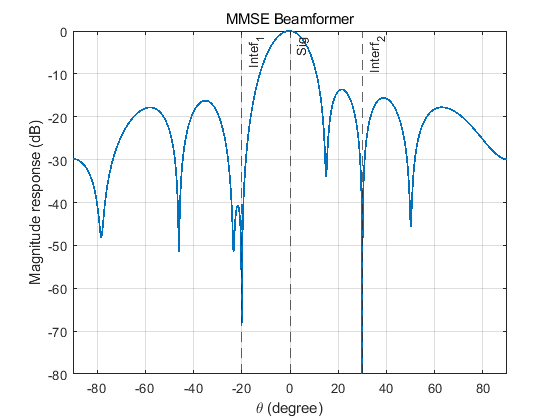

In [3]:

R = X*X'/K;
p = X*r'/K;
w_opt = R\p;
theta_plot = -90:0.1:90;
D_plot = steering_vector(theta_plot);     % M×Ntheta
P_LS_0 = w_opt'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);
xline(theta,'--',{'Sig','Intef_1','Interf_2'})
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('MMSE Beamformer');


This approach has the same form as a Wiener filter; it is the Wiener solution in the minimum\-mean\-square\-error sense, i.e., an MMSE beamformer. Matrix inversion is usually expensive, however, and the Wiener solution must be recomputed whenever new snapshots are added. For continuous operation, it is preferable to update the beamformer weights using each new snapshot. This leads to iterative algorithms. The least mean squares (LMS) algorithm described below performs adaptive updates using gradient descent and updates the weight vector for every new snapshot.


As stated above, the cost function under the minimum\-mean\-square\-error criterion is


$$\begin{array}{l} J=e[n]e^* [n]\\ =(r[n]-w^H x[n])(r[n]-w^H x[n])^* \\ =r[n]r^* [n]+w^H x[n]x^H [n]w-w^H x[n]r^* [n]-x^H [n]r[n]w\\ =\sigma^2 +w^H {\hat{R} }_{xx} w-w^H \hat{p} -{\hat{p} }^H w \end{array}$$

Taking the Wirtinger derivative of the cost function gives its gradient:


$$\begin{array}{l} \nabla J={\hat{R} }_{xx} w-\hat{p} \\ =x[n]x^H [n]w-x[n]r^* [n]\\ =x[n]\lbrace x^H [n]w-r^* [n]\rbrace \\ =-x[n]e^* [n] \end{array}$$

Gradient descent can update the weight vector and iteratively minimize the cost function. It updates the variable in the negative\-gradient direction using a chosen step size, so


$$w[n]=w[n-1]+\mu x[n]e^* [n]$$

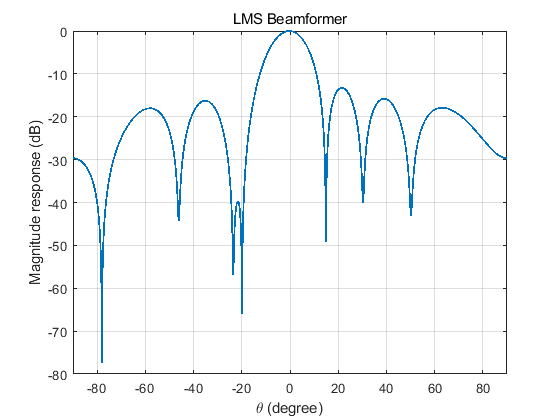

In [4]:

w = zeros(M,1);%initialize the weight vector to zero
mu = 0.00005;
for i = 1:K
    xn = X(:,i);
    rn = r(i);
    e = rn-w'*xn;
    w = w+mu*xn*e';
end

P_LS_0 = w'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);

xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('LMS Beamformer')

### RLS Beamformer

The LMS method is based on gradient descent. Its drawback is that the step size is fixed and can be difficult to tune.


This motivates the recursive least\-squares filter.


The preceding cost function is a sum of squared errors. A forgetting factor is introduced so that, in a time\-varying environment, more recent data receive greater weight; regularization is also used to keep the weight coefficients from becoming too large. The cost function becomes


$$J(w)=\sum_{i=1}^n \lambda^{n-i} |e(n)|^2 +\delta \lambda^n ||w(n)||^2$$

The first term is the error term. The forgetting factor is less than 1, reflecting the greater emphasis placed on recent snapshots. The second term is a regularization term that limits the weight magnitudes when few snapshots are available and gradually weakens as the number of snapshots increases. Expanding the expression gives


$$\begin{array}{l} J(w)=\sum_{i=1}^n \lambda^{n-i} (r[i]-w^H (n)x[i])(r[i]-w^H (n)x[i])^* +\delta \lambda^n w^H (n)w(n)\\ =\sum_{i=1}^n \lambda^{n-i} (r[i]r^* [i]+w^H (n)x[i]x^H [i]w(n)-w^H (n)x[i]r^* [i]-x^H [i]r[i]w(n))+\delta \lambda^n w^H (n)w(n)\\ =\sum_{i=1}^n \lambda^{n-i} r[i]r^* [i]+\sum_{i=1}^n \lambda^{n-i} w^H (n)x[i]x^H [i]w(n)-\sum_{i=1}^n \lambda^{n-i} w^H (n)x[i]r^* [i]-\sum_{i=1}^n \lambda^{n-i} x^H [i]r[i]w(n)+\delta \lambda^n w^H (i)w(n) \end{array}$$

Differentiate the cost function with respect to $w^H$ :


$$\frac{\partial J(w)}{\partial w^* }=\sum_{i=1}^n \lambda^{n-i} x[i]x^H [i]w(n)-\sum_{i=1}^n \lambda^{n-i} x[i]r^* [i]+\delta \lambda^n w(n)$$

Let


$${\hat{R} }_{xx} (n)=\sum_{i=1}^n \lambda^{n-i} x[i]x^H [i],\hat{p} (n)=\sum_{i=1}^n \lambda^{n-i} x[i]r^* [i]$$

. The expression can be simplified to


 $\frac{\partial J(w)}{\partial w^* }={\hat{R} }_{xx} (n)w(n)-\hat{p} (n)+\delta \lambda^n w(n)=({\hat{R} }_{xx} (n)+\delta \lambda^n I)w(n)-\hat{p} (n)$ Setting the partial derivative to zero gives


. Therefore, the optimal weights are


$$w_{opt} (n)=({\hat{R} }_{xx} (n)+\delta \lambda^n I)^{-1} \hat{p} (n)$$

Assume $P(n)=({\hat{R} }_{xx} +\delta \lambda^n I)^{-1}$ . Then $w_{opt} (n)=P(n)\hat{p} (n)$


Consider time instant $n-1$ .


$${\hat{R} }_{xx} (n-1)=\sum_{i=1}^{n-1} \lambda^{n-1-i} x[i]x^H [i]$$

Then


$${\hat{R} }_{xx} (n)=\lambda {\hat{R} }_{xx} (n-1)+x[n]x^H [n]$$

. Therefore,


$$\begin{array}{l} P^{-1} (n)=\lambda P^{-1} (n-1)+x[n]x^H [n],\\ \hat{p} (n)=\lambda \hat{p} (n-1)+x[n]r^* [n] \end{array}$$

Applying the matrix inversion lemma (the Sherman\-Morrison formula),


$$(A+UBV)^{-1} =A^{-1} -A^{-1} UBVA^{-1} (I+UBVA^{-1} )^{-1}$$

in particular, for $A+uv^H$ , which is also called a rank\-one correction,


$$(A+uv^H )^{-1} =A^{-1} -\frac{A^{-1} uv^H A^{-1} }{1+v^H A^{-1} u}$$

we obtain


$$\begin{array}{l} P(n)=(\lambda P^{-1} (n-1)+x[n]x^H [n])^{-1} \\ =\frac{1}{\lambda }P(n-1)-\frac{\frac{1}{\lambda }P(n-1)x[n]x^H [n]\frac{1}{\lambda }P(n-1)}{1+\frac{1}{\lambda }x^H [n]P(n-1)x(n)}\\ =\frac{1}{\lambda }\lbrace P(n-1)-\frac{P(n-1)x[n]x^H [n]P(n-1)}{\lambda +x^H [n]P(n-1)x(n)}\rbrace  \end{array}$$

Define $k(n)=\frac{P(n-1)x(n)}{\lambda +x^H [n]P(n-1)x(n)}$


. Then $P(n)=\frac{1}{\lambda }\lbrace P(n-1)-k(n)x^H (n)P(n-1)\rbrace$


Note that


$$\begin{array}{l} P(n)x(n)=\frac{1}{\lambda }\lbrace P(n-1)-k(n)x^H (n)P(n-1)\rbrace x(n)\\ =\frac{1}{\lambda }\lbrace P(n-1)x(n)-k(n)x^H (n)P(n-1)x(n)\rbrace  \end{array}$$

. Let $q(n)=x^H (n)P(n-1)x(n)$


$$\begin{array}{l} P(n)x(n)=\frac{1}{\lambda }\lbrace P(n-1)x(n)-\frac{P(n-1)x(n)}{\lambda +q(n)}q(n)\rbrace \\ =\frac{1}{\lambda }P(n-1)x(n)\lbrace 1-\frac{q(n)}{\lambda +q(n)}\rbrace \\ =\frac{P(n-1)x(n)}{\lambda +q(n)}\\ =k(n) \end{array}$$

. The recursion for the optimal weights can be rewritten as


$$\begin{array}{l} w_{opt} (n)=\frac{1}{\lambda }\lbrace P(n-1)-k(n)x^H (n)P(n-1)\rbrace [\lambda \hat{p} (n-1)+x(n)r^* (n)]\\ =P(n-1)\hat{p} (n-1)-k(n)x^H (n)P(n-1)\hat{p} (n-1)+\frac{1}{\lambda }P(n-1)x(n)r^* (n)-\frac{1}{\lambda }k(n)x^H (n)P(n-1)x(n)r^* (n)\\ =w_{opt} (n-1)-k(n)x^H (n)w_{opt} (n-1)+\frac{1}{\lambda }P(n-1)x(n)r^* (n)-\frac{1}{\lambda }k(n)q(n)r^* (n)\\ =w_{opt} (n-1)-k(n)x^H (n)w_{opt} (n-1)+\frac{1}{\lambda }r^* (n)[P(n-1)x(n)-\frac{P(n-1)x(n)}{\lambda +q(n)}q(n)]\\ =w_{opt} (n-1)-k(n)x^H (n)w_{opt} (n-1)+\frac{1}{\lambda }r^* (n)P(n-1)x(n)[1-\frac{q(n)}{\lambda +q(n)}]\\ =w_{opt} (n-1)-k(n)x^H (n)w_{opt} (n-1)+k(n)r^* (n)\\ =w_{opt} (n-1)+k(n)[r^* (n)-x^H (n)w_{opt} (n-1)] \end{array}$$

Define the a priori error $e(n)=r(n)-w_{opt}^H (n-1)x(n)$


. The final recursion is


$$w_{opt} (n)=w_{opt} (n-1)+k(n)e^* (n)$$

 $P(n)$ Initialize with $P(0)=\delta^{-1} I$


In [5]:

factor = 0.995%forgetting factor

factor = 0.9950

In [6]:
w = zeros(M,1);%initialize the weight vector to zero
delta = 0.1%regularization factor: use a smaller value at high SNR and a larger value at low SNR

delta = 0.1000

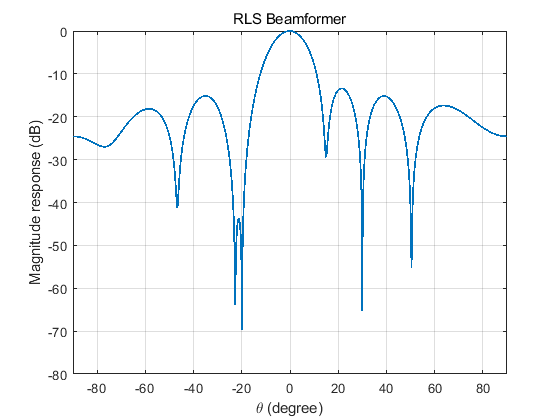

In [7]:
P = eye(size(R))/delta;
for i = 1:K
    xn = X(:,i);
    rn = r(i);
    e = rn-w'*xn;
    q = xn'*P*xn;
    k = (P*xn)/(factor+q);
    w = w+k*e';
   P = (P-k*xn'*P)/factor;
end

P_LS_0 = w'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);

xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('RLS Beamformer')